# Experiment Report — Event-Driven AI Financial Advisor

Tracks every training + backtest run logged in `data/4_experiments/experiment_log.csv`,
using a two-tier evaluation approach, fixed before the first run and kept
consistent across every later change so results stay comparable:

- **Tier 1** (`accuracy`, `precision`) — fast per-step sanity check on model quality
- **Tier 2** (`total_return`, `win_rate`, `max_drawdown`, `sharpe`) — the true
  cross-step gate, computed from actual backtested trade outcomes

Re-run this notebook after every new run is logged. Fill in the **Stage** sections
at the bottom as each experiment step is completed — that narrative is what
goes into the report's Evaluation chapter.


In [1]:
import sys, os

# Jupyter's cwd is this notebook's own folder, not the project root - chdir
# so the data/ and src/ relative paths used throughout the codebase resolve
# the same way here as they do when a script is run from the project root.
PROJECT_ROOT = os.path.abspath("..")
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
from src.utils import experiment_log, experiment_charts as ec

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 140)


## All runs

Full log, with `config_json` expanded into its own columns. Runs are labeled
`Run 1, Run 2, ...` in chronological order rather than shown by `run_id` -
`run_id` embeds the real timestamp each run was created at (see
`experiment_log.new_run_id`), which isn't something the report needs to show.


In [2]:
log_df = experiment_log.load_experiment_log()
ec.report_table(log_df)


,Run_Label,config_json,accuracy,precision,total_return,win_rate,max_drawdown,sharpe,config_universe,config_n_rows
0,Run 1,{},0.568204,0.529769,NaN,NaN,NaN,NaN,NaN,NaN
1,Run 2,"{""universe"": ""current_only"", ""n_rows"": 42575}",0.575014,0.521599,NaN,NaN,NaN,NaN,current_only,42575.0
2,Run 3,"{""universe"": ""all_incl_delisted"", ""n_rows"": 51875}",0.563360,0.521202,NaN,NaN,NaN,NaN,all_incl_delisted,51875.0
3,Run 4,{},0.563360,0.521202,-0.107299,0.499794,-0.767663,0.378406,NaN,NaN
4,Run 5,"{""universe"": ""current_only"", ""n_rows"": 42575}",0.575014,0.521599,5.948502,0.528691,-0.426243,1.995847,current_only,42575.0
5,Run 6,"{""universe"": ""all_incl_delisted"", ""n_rows"": 51875}",0.563360,0.521202,-0.107299,0.499794,-0.767663,0.378406,all_incl_delisted,51875.0


## What changed between runs

For each run after the first: which config key(s) changed vs. the immediately
preceding run, and how much each metric moved as a result. This is the
"what changed → what happened" record for the report — no need to
hand-track it separately.


In [3]:
diff_df = ec.diff_config_between_runs(log_df)
diff_df


,run_label,prev_run_label,config_changed,accuracy_delta,precision_delta,total_return_delta,win_rate_delta,max_drawdown_delta,sharpe_delta
0,Run 2,Run 1,"{'universe': (nan, 'current_only'), 'n_rows': (nan, 42575.0)}",0.006809,-0.008170,NaN,NaN,NaN,NaN
1,Run 3,Run 2,"{'universe': ('current_only', 'all_incl_delisted'), 'n_rows': (42575.0, 51875.0)}",-0.011654,-0.000397,NaN,NaN,NaN,NaN
2,Run 4,Run 3,"{'universe': ('all_incl_delisted', nan), 'n_rows': (51875.0, nan)}",0.000000,0.000000,NaN,NaN,NaN,NaN
3,Run 5,Run 4,"{'universe': (nan, 'current_only'), 'n_rows': (nan, 42575.0)}",0.011654,0.000397,6.055801,0.028897,0.34142,1.617441
4,Run 6,Run 5,"{'universe': ('current_only', 'all_incl_delisted'), 'n_rows': (42575.0, 51875.0)}",-0.011654,-0.000397,-6.055801,-0.028897,-0.34142,-1.617441


## Tier 1 — model-quality trend

Valid only *within* a step where the label definition hasn't changed.

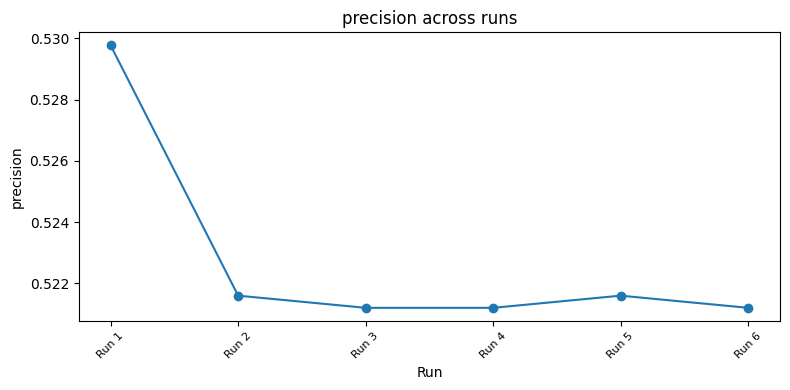

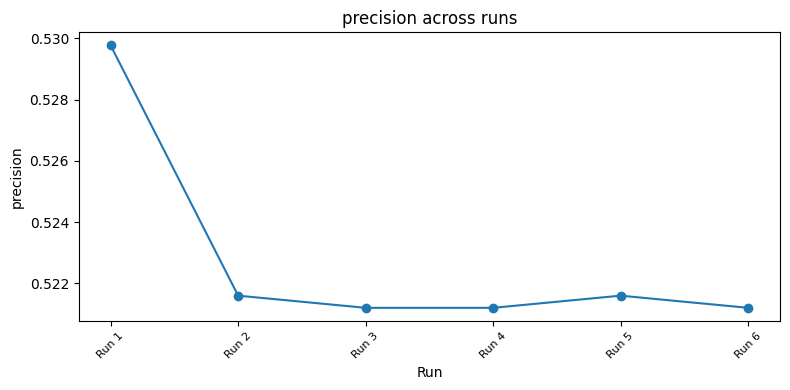

In [4]:
ec.plot_metric_trend("precision", log_df=log_df)


## Tier 2 — financial trend

The cross-step gate — comparable across every step of the sweep, regardless of internal model/label changes.

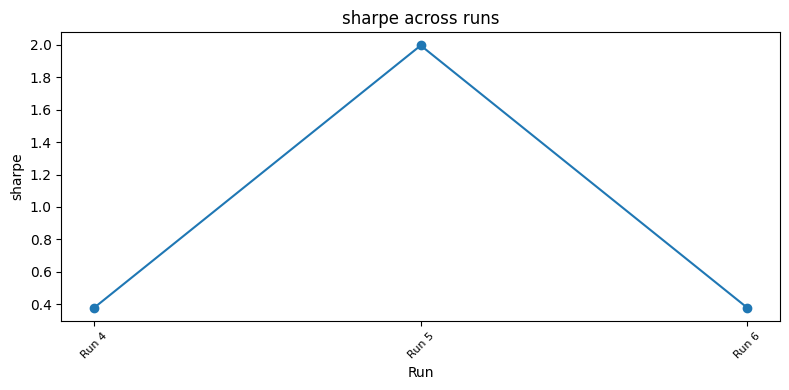

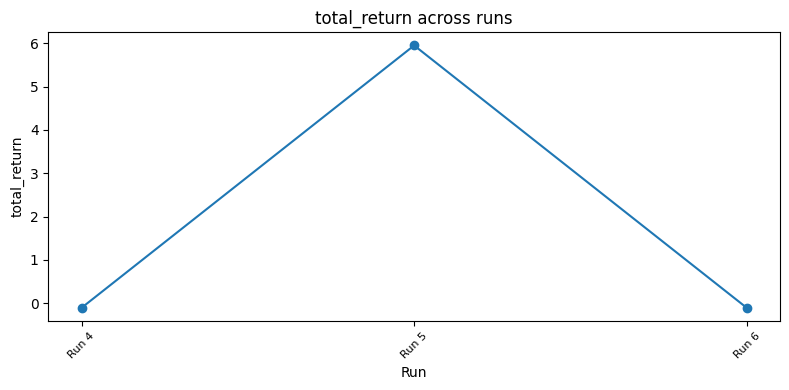

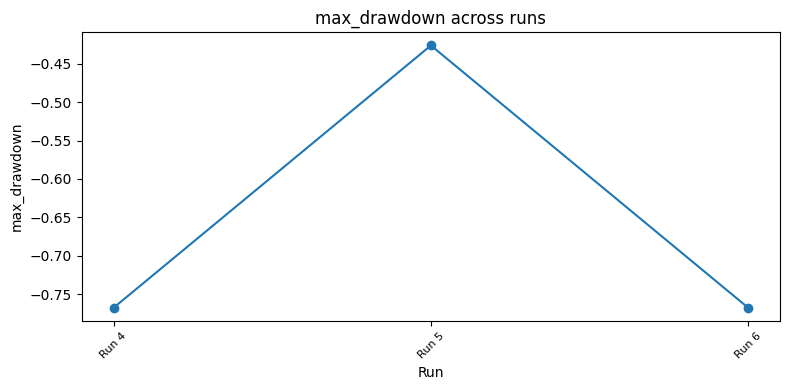

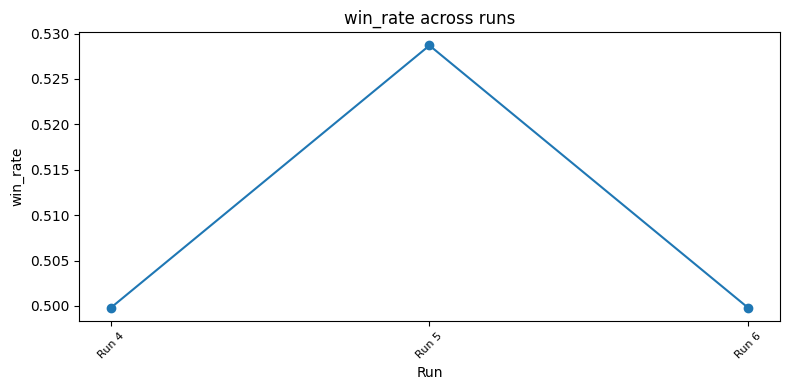

In [5]:
for metric in ["sharpe", "total_return", "max_drawdown", "win_rate"]:
    ec.plot_metric_trend(metric, log_df=log_df)


## Precision vs. Sharpe

Did a Tier 1 (precision) improvement actually pay off at Tier 2 (Sharpe)? A run that
moves up-and-right improved on both; up-and-left means Tier 1 improved but the
financial result got worse — a sign the model is overfitting to the label, not
learning something that survives contact with real trade outcomes.


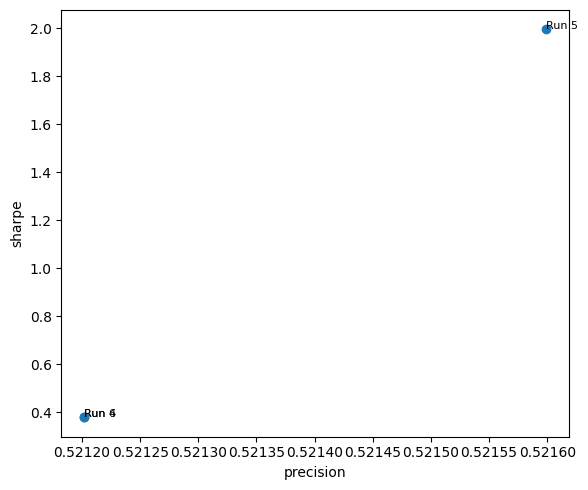

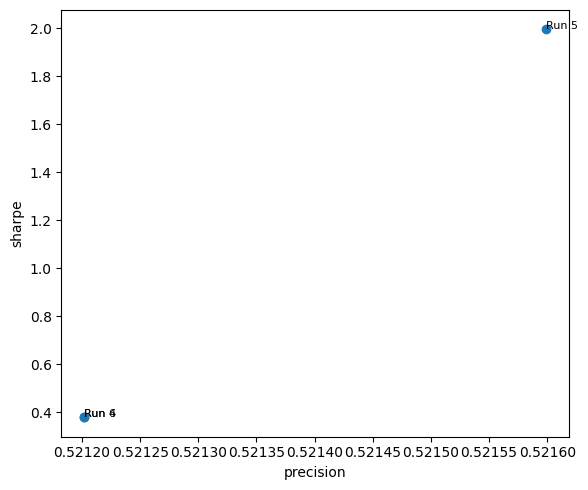

In [6]:
ec.plot_tradeoff("precision", "sharpe", log_df=log_df)


## Best runs so far

Top runs ranked by Sharpe (the primary Tier 2 metric), Max Drawdown as the
hard constraint — a new run only replaces the current champion if Sharpe
improves *and* drawdown doesn't breach the limit.


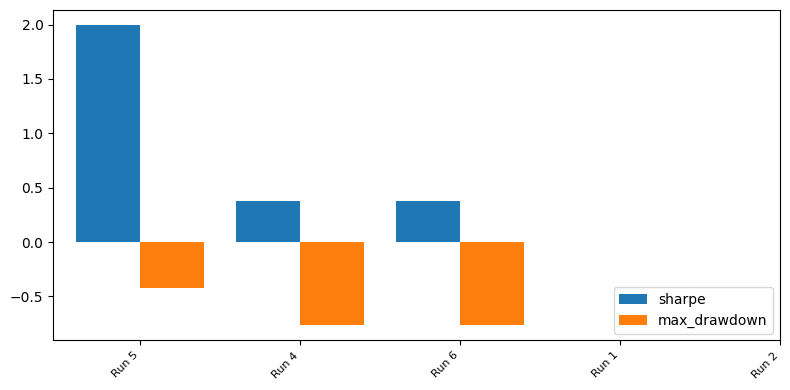

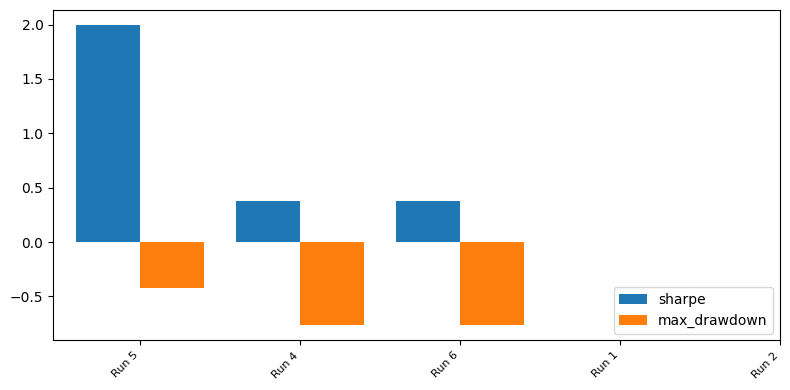

In [7]:
ec.plot_metric_comparison(["sharpe", "max_drawdown"], log_df=log_df, top_n=5)


---
# Stage-by-stage findings

One section per experiment step. Fill in as each step is completed — this
is the raw material for the report's Evaluation chapter.


### Stage 1 — Baseline

**Parameter(s):** `no scale_pos_weight, no triple-barrier, no SUE, no regime filter`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_


### Stage 2 — `scale_pos_weight` (class imbalance)

**Parameter(s):** `scale_pos_weight`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_


### Stage 3 — Triple-barrier labeling

**Parameter(s):** `take_profit / stop_loss / max_holding_days`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_


### Stage 4 — SUE surprise normalization

**Parameter(s):** `normalize_earnings_surprise(method=\"sue\")`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_


### Stage 5 — 200-day SMA regime filter

**Parameter(s):** `apply_regime_filter(sma_window)`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_


### Stage 6 — Meta-labeling

**Parameter(s):** `second-stage classifier config`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_
